# Week 9: Data Visualisation with `matplotlib` - Class Exercises

We first load the packages necessary for this exercise.\
**Use `matplotlib` for this exercise.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')         # we will use the `ggplot` style sheet

---
## 1. Olympic Games

We will work with the Olympics Medals data from `TidyTuesday` (https://github.com/rfordatascience/tidytuesday/tree/main/data/2021/2021-07-27)

The data set `olympics` contains information on Olympic athletes, including their unique ID, name, sex, age, team, and the year they participated.\
An athlete can appear multiple times in the data if they participated in more than one event in the same year.\
Download the file `olympics.csv` from `Canvas` or `TidyTuesday` and save it in your `data` sub-folder.

We want to visualize the age distribution of athletes in the 1980, 1996, and 2012 Summer Olympics. 

(a)  Prepare the data as necessary. Display the first 10 rows, which should look like this:

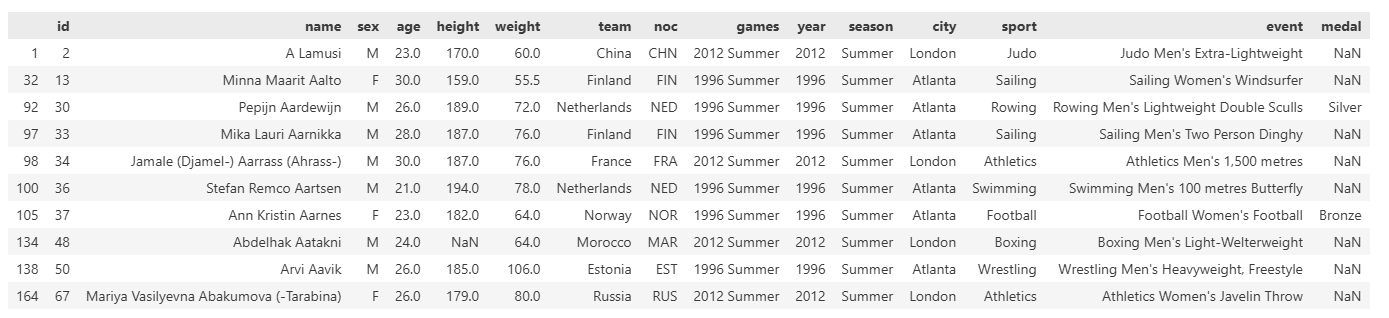

**Hint**\
You will need to remove duplicates for athletes who take part in more than one event in the same year.\
Read more about `drop_duplicates` here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html

In [2]:
# Type your code here:
# Load the data
olympics = pd.read_csv("data/olympics.csv")

# Filter for Summer Olympics in 1980, 1996, and 2012
years = [1980, 1996, 2012]
df = olympics[(olympics["season"] == "Summer") & (olympics["year"].isin(years))]

# Remove duplicate athletes who competed in more than one event in the same year
df = df.drop_duplicates(subset=["id", "year"])

# Keep only relevant columns and reset index
df = df[["id", "name", "sex", "age", "team", "year"]].reset_index(drop=True)

# Display first 10 rows
print(df.head(10))

   id                                     name sex   age         team  year
0   2                                 A Lamusi   M  23.0        China  2012
1  13                       Minna Maarit Aalto   F  30.0      Finland  1996
2  30                         Pepijn Aardewijn   M  26.0  Netherlands  1996
3  33                      Mika Lauri Aarnikka   M  28.0      Finland  1996
4  34       Jamale (Djamel-) Aarrass (Ahrass-)   M  30.0       France  2012
5  36                     Stefan Remco Aartsen   M  21.0  Netherlands  1996
6  37                       Ann Kristin Aarnes   F  23.0       Norway  1996
7  48                         Abdelhak Aatakni   M  24.0      Morocco  2012
8  50                               Arvi Aavik   M  26.0      Estonia  1996
9  67  Mariya Vasilyevna Abakumova (-Tarabina)   F  26.0       Russia  2012


(b) Re-create the three histograms below (one for each year) that show the age distributions of athletes.

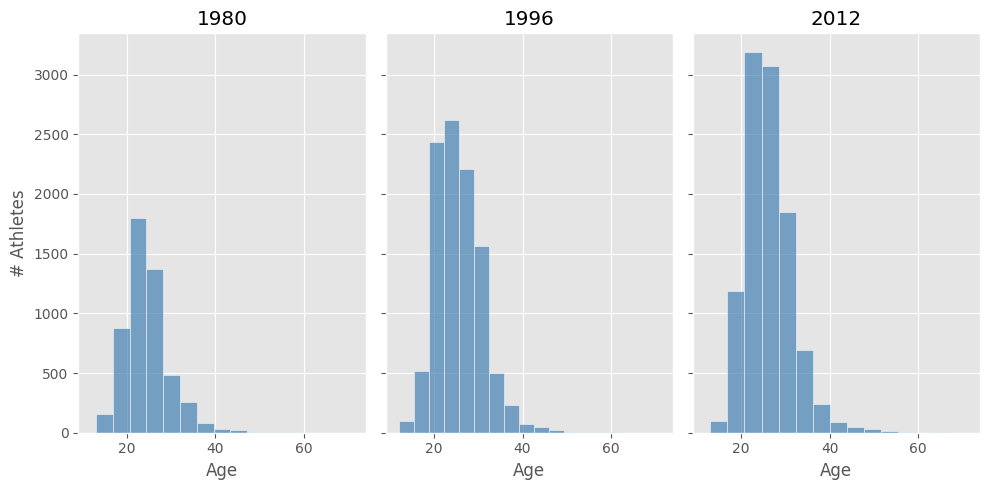

**Hint:** Use 15 bins for the histograms.

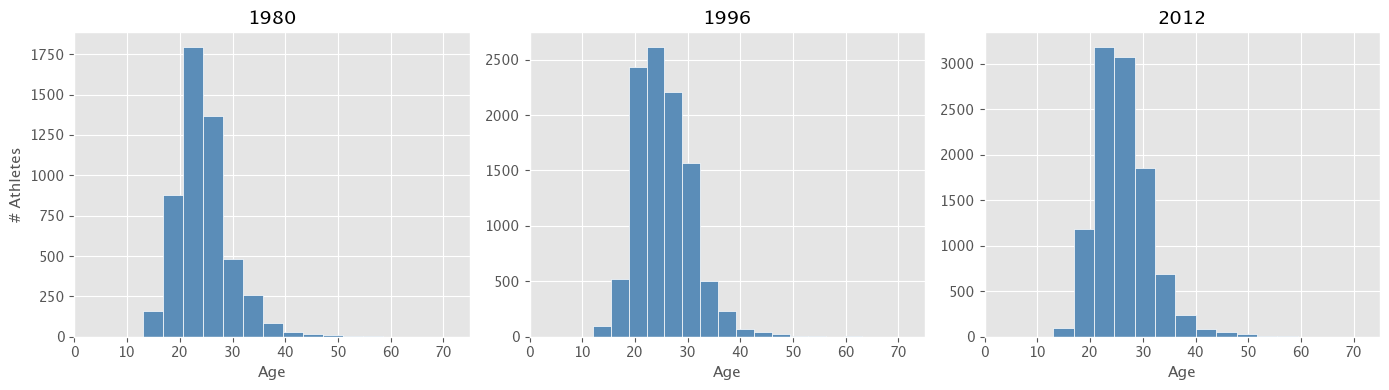

In [3]:


years = [1980, 1996, 2012]
df = olympics[(olympics["season"] == "Summer") & (olympics["year"].isin(years))]
df = df.drop_duplicates(subset=["id", "year"])

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, year in zip(axes, years):
    data = df[df["year"] == year]["age"].dropna()
    ax.hist(data, bins=15, color="#5B8DB8", edgecolor="white", linewidth=0.5)
    ax.set_title(str(year), fontsize=14, fontweight="bold")
    ax.set_xlabel("Age", fontsize=11)
    ax.set_xlim(0, 75)
    ax.set_facecolor("#E5E5E5")
    ax.grid(True, color="white", linewidth=0.8)
    ax.set_axisbelow(True)

axes[0].set_ylabel("# Athletes", fontsize=11)

fig.tight_layout()
plt.savefig("olympics_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Cereal Consumptions

The file `cereal_2019_20.xlsx` (download from `Canvas`) contains monthly cereal consumption (in billion dollars) in the US for 2019 and 2020.

It also shows the year-on-year difference between 2020 and 2019. The first few rows of the data set are listed below.

In [4]:
import sys
print(sys.executable)

/Users/XuanNguyen/Documents/NUS/DSS5201/dss5201-weekly/src/venv-dss5201/bin/python


In [5]:
import sys
import subprocess
subprocess.run([sys.executable, "--version"], capture_output=True, text=True).stdout


'Python 3.12.10\n'

In [6]:
import sys
print("Python:", sys.executable)
print("Version:", sys.version)

import subprocess
result = subprocess.run([sys.executable, "-m", "pip", "install", "openpyxl"], 
                       capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Python: /Users/XuanNguyen/Documents/NUS/DSS5201/dss5201-weekly/src/venv-dss5201/bin/python
Version: 3.12.10 (main, Apr  8 2025, 11:35:47) [Clang 17.0.0 (clang-1700.0.13.3)]


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [openpyxl]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Users/XuanNguyen/Documents/NUS/DSS5201/dss5201-weekly/src/venv-dss5201/bin/python -m pip install --upgrade pip



In [7]:

df = pd.read_excel('data/cereal_2019_20.xlsx')   
df.head()

,Month,2019,2020,diff
0,Jan,54.542,54.140,-0.402
1,Feb,53.286,54.048,0.762
2,Mar,54.241,68.607,14.366
3,Apr,54.527,59.954,5.427
4,May,54.814,61.181,6.367


(a) Re-create, as closely as you can, the dodged bar chart below comparing cereal consumption in 2019 and 2020.

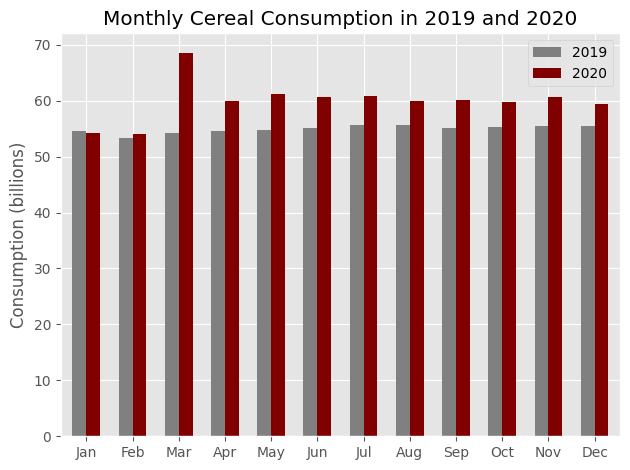

**Hint**\
Use `plot.bar` from `pandas`. Read more here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html\
If you run into trouble referring to the columns by their labels, try referring to them by their positions.

In [8]:
df = pd.read_excel('data/cereal_2019_20.xlsx')
print(df.columns.tolist())
print(df.head())

['Month', 2019, 2020, 'diff']
  Month    2019    2020    diff
0   Jan  54.542  54.140  -0.402
1   Feb  53.286  54.048   0.762
2   Mar  54.241  68.607  14.366
3   Apr  54.527  59.954   5.427
4   May  54.814  61.181   6.367


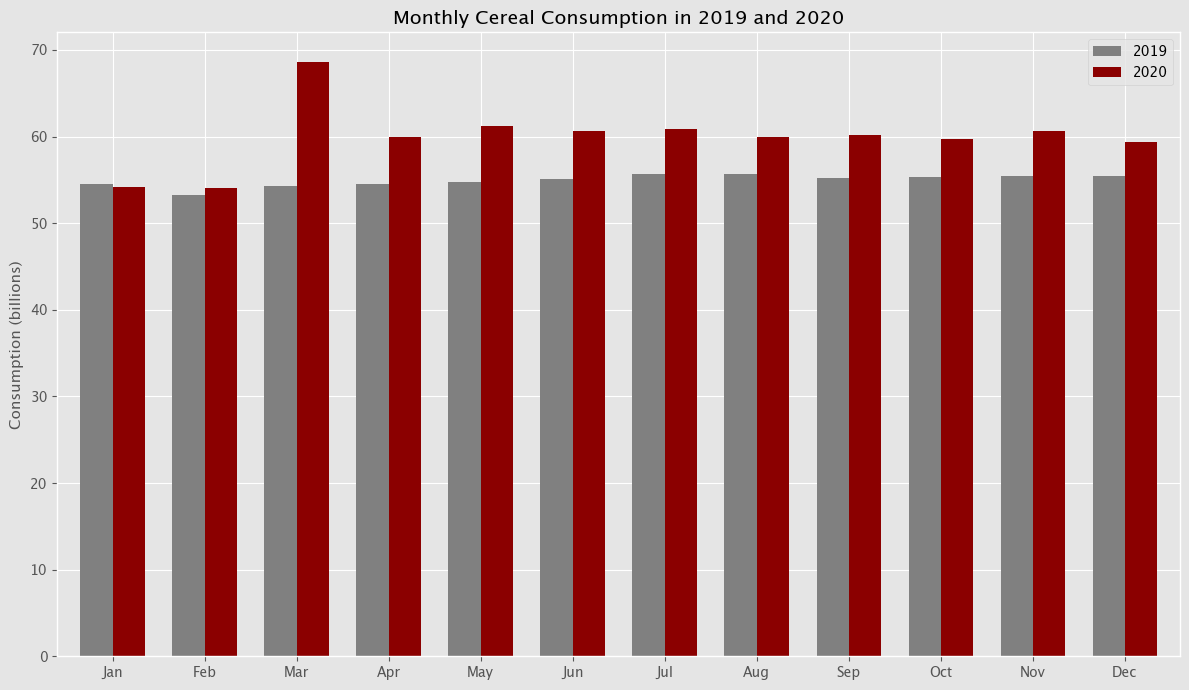

In [9]:
# Type your code here:
df = pd.read_excel('data/cereal_2019_20.xlsx')

plot_df = df[['Month', 2019, 2020]].set_index('Month')

ax = plot_df.plot.bar(
    figsize=(12, 7),
    color={2019: 'gray', 2020: 'darkred'},
    edgecolor='none',
    width=0.7
)

ax.set_title('Monthly Cereal Consumption in 2019 and 2020', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Consumption (billions)', fontsize=11)
ax.set_xticklabels(plot_df.index, rotation=0)
ax.set_facecolor('#E5E5E5')
ax.figure.patch.set_facecolor('#E5E5E5')
ax.grid(True, axis='y', color='white', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(['2019', '2020'])

plt.tight_layout()
plt.show()

(b) The bar plot above displays cereal consumption in 2019 and 2020. It shows the absolute levels of consumption directly.\
However, viewers have to make the comparison themselves by visually evaluating the difference in the heights of *adjacent bars*.\
We now explore alternative ways to present the same data.

Re-create the following line plot which emphasises the seasonal patterns and trend between years.

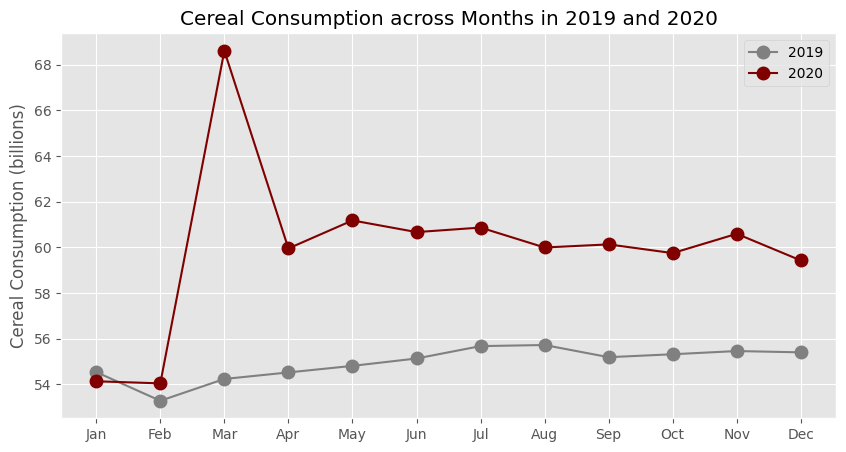

**Hint:**
- Read up on `ax.plot`: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html
- Read up on `ax.legend`: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html

/var/folders/ys/p07ql4sx001fklpgvlls_rjm0000gp/T/ipykernel_30333/2683232024.py:17: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(['2019', '2020'], handles=[


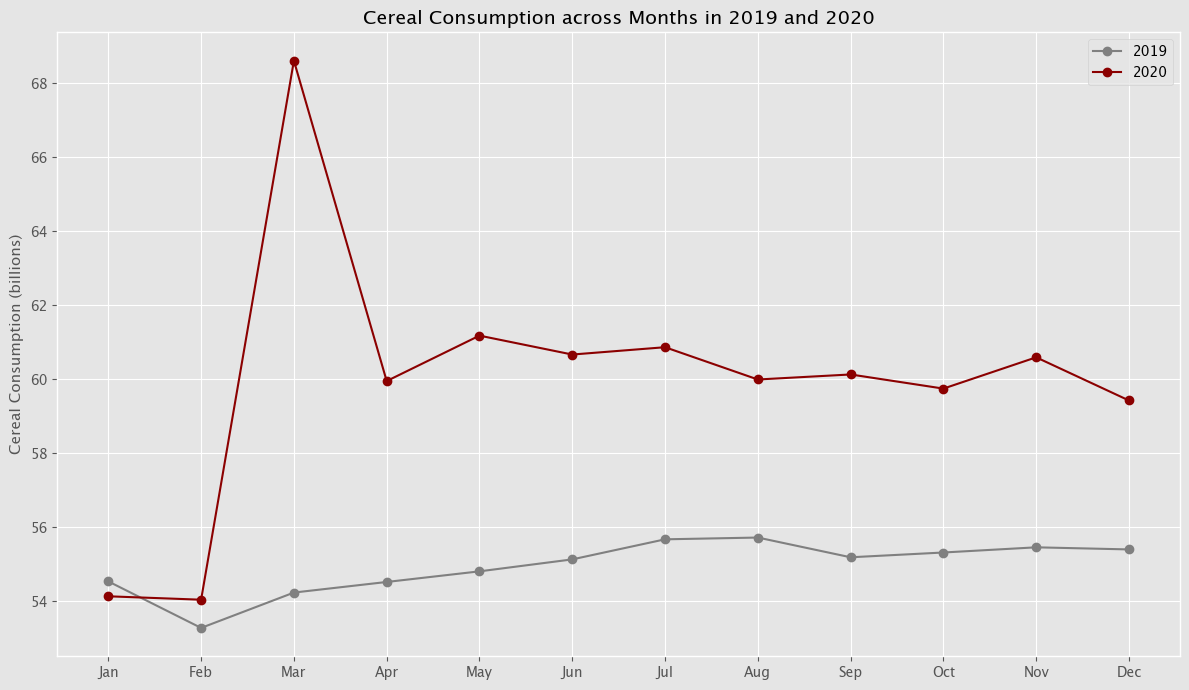

In [10]:
# Type your code here:
df = pd.read_excel('data/cereal_2019_20.xlsx')
plot_df = df[['Month', 2019, 2020]].set_index('Month')

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(plot_df.index, plot_df[2019], color='gray',   marker='o', label='2019')
ax.plot(plot_df.index, plot_df[2020], color='darkred', marker='o', label='2020')

ax.set_title('Cereal Consumption across Months in 2019 and 2020', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Cereal Consumption (billions)', fontsize=11)
ax.set_facecolor('#E5E5E5')
ax.figure.patch.set_facecolor('#E5E5E5')
ax.grid(True, color='white', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(['2019', '2020'], handles=[
    plt.Line2D([0], [0], color='gray',    marker='o', label='2019'),
    plt.Line2D([0], [0], color='darkred', marker='o', label='2020')
])

plt.tight_layout()
plt.show()